In [2]:
%pip install shap xgboost lightgbm imbalanced-learn scikit-learn pandas numpy optbinning

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install matplotlib seaborn scorecardpy mlflow fastapi uvicorn joblib pandera

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import warnings, os, json
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import joblib

In [5]:
from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from sklearn.preprocessing     import OneHotEncoder, StandardScaler
from sklearn.impute             import SimpleImputer
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics           import (
    roc_auc_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, brier_score_loss
)
from sklearn.calibration       import calibration_curve, CalibratedClassifierCV

from imblearn.over_sampling    import SMOTE
from imblearn.pipeline         import Pipeline as ImbPipeline

import xgboost  as xgb
import lightgbm as lgb
import shap

In [6]:
df = pd.read_csv("credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [8]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [9]:
print("\nTarget distribution:")
print(df["loan_status"].value_counts(normalize=True).rename({0:"Paid",1:"Default"}).map("{:.1%}".format))
print(f"\nDefault rate: {df['loan_status'].mean():.2%}")


Target distribution:
loan_status
Paid       78.2%
Default    21.8%
Name: proportion, dtype: object

Default rate: 21.82%


In [10]:
df.shape

(32581, 12)

In [11]:
missing = (df.isnull().sum()
             .to_frame("count")
             .assign(pct=lambda x: x["count"]/len(df)*100)
             .query("count > 0")
             .sort_values("pct", ascending=False))
print(missing.to_string())

                   count       pct
loan_int_rate       3116  9.563856
person_emp_length    895  2.747000


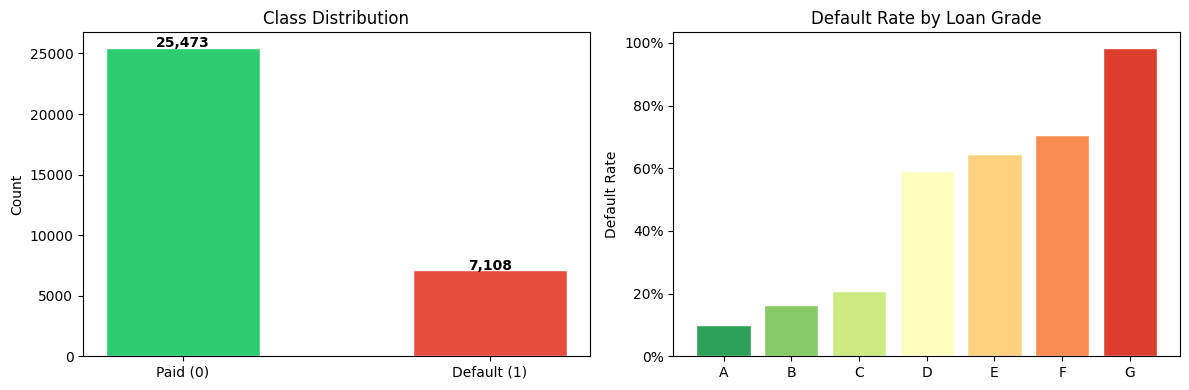

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["loan_status"].value_counts()
axes[0].bar(["Paid (0)", "Default (1)"], counts.values,
            color=["#2ecc71", "#e74c3c"], edgecolor="white", width=0.5)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")

# Default rate by loan grade
grade_default = df.groupby("loan_grade")["loan_status"].mean().sort_index()
axes[1].bar(grade_default.index, grade_default.values,
            color=sns.color_palette("RdYlGn_r", len(grade_default)), edgecolor="white")
axes[1].set_title("Default Rate by Loan Grade")
axes[1].set_ylabel("Default Rate")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()


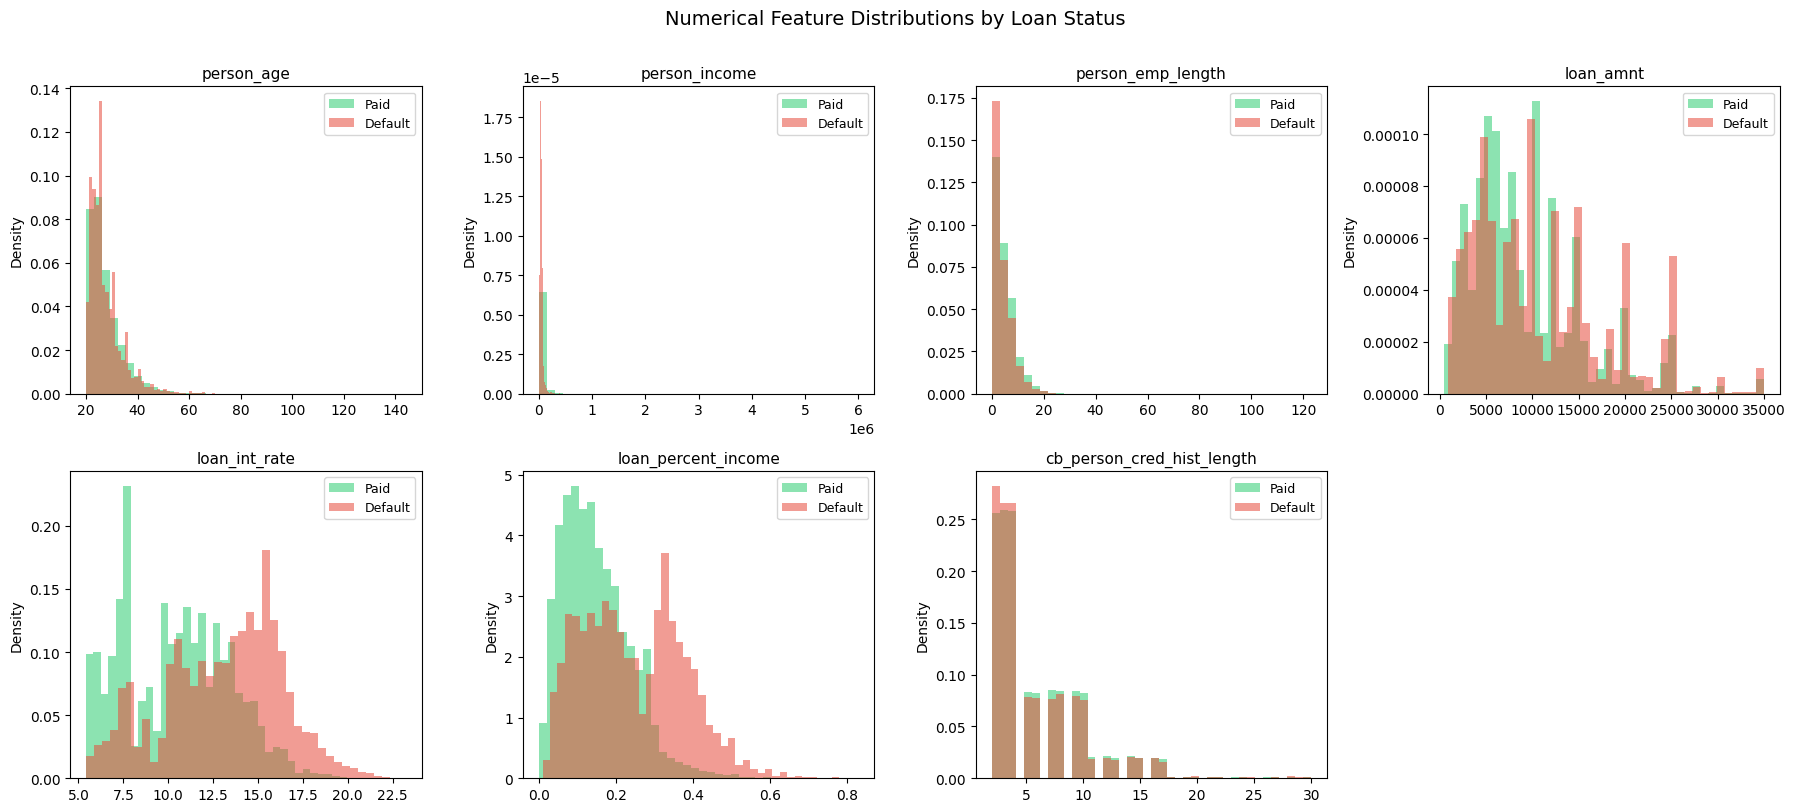

In [13]:
num_features = ["person_age","person_income","person_emp_length",
                "loan_amnt","loan_int_rate","loan_percent_income",
                "cb_person_cred_hist_length"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    for label, colour in zip([0, 1], ["#2ecc71", "#e74c3c"]):
        axes[i].hist(df.loc[df["loan_status"]==label, col].dropna(),
                     bins=40, alpha=0.55, color=colour,
                     label="Paid" if label==0 else "Default", density=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)
plt.suptitle("Numerical Feature Distributions by Loan Status", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

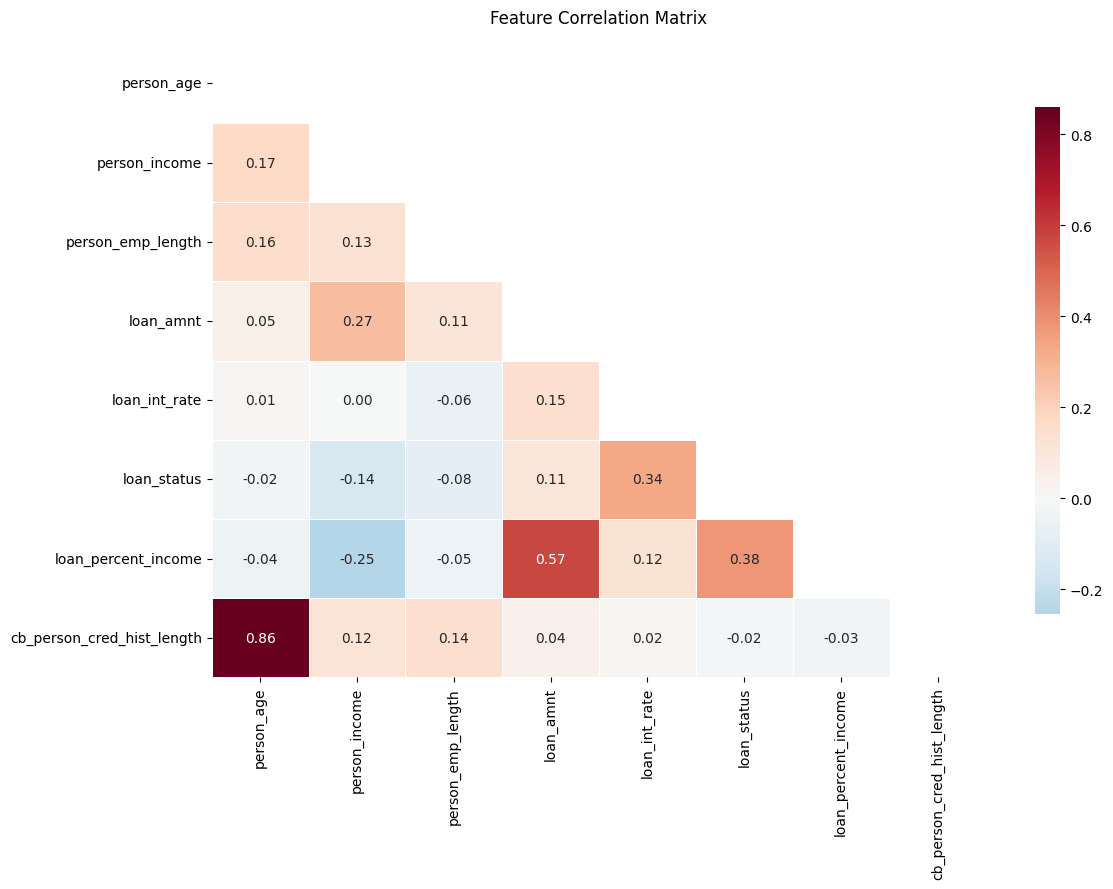


Top correlations with loan_status:
loan_percent_income           0.379366
loan_int_rate                 0.335133
person_income                -0.144449
loan_amnt                     0.105376
person_emp_length            -0.082489
person_age                   -0.021629
cb_person_cred_hist_length   -0.015529
Name: loan_status, dtype: float64


In [14]:
num_df = df.select_dtypes(include=["int64","float64"])
corr = num_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.4, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", pad=15)
plt.tight_layout()
plt.show()

print("\nTop correlations with loan_status:")
print(corr["loan_status"].drop("loan_status").sort_values(key=abs, ascending=False))

In [15]:
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

# Business-rule validation 
invalid = pd.Series(False, index=df.index)
invalid |= (df["person_age"]   < 18) | (df["person_age"]   > 100)
invalid |= df["person_income"] <= 0
invalid |= df["loan_amnt"]     <= 0
invalid |= df["loan_amnt"]     > 10 * df["person_income"]          # extreme DTI
if "loan_int_rate" in df.columns:
    invalid |= df["loan_int_rate"].notna() & (df["loan_int_rate"] > 60)
print(f"Invalid rows flagged: {invalid.sum()} ({invalid.mean():.2%}) → removed")
df = df[~invalid].reset_index(drop=True)

# Missing-value flags (preserve signal before imputation)
for col in ["person_emp_length", "loan_int_rate"]:
    df[f"{col}_missing"] = df[col].isnull().astype(int)

print(f"\nFinal clean shape: {df.shape}")

Duplicates removed: 165
Invalid rows flagged: 5 (0.02%) → removed

Final clean shape: (32411, 14)


In [16]:
# Feature engineering

# Debt-to-income ratio (loan amount / annual income)
df["dti_ratio"] = df["loan_amnt"] / (df["person_income"] + 1)

# Income tier (log-transform to compress skew)
df["log_income"] = np.log1p(df["person_income"])

# Loan-to-credit-history ratio
df["loan_per_hist_year"] = df["loan_amnt"] / (df["cb_person_cred_hist_length"] + 1)

# Age-employment ratio (stability indicator)
df["age_emp_ratio"] = df["person_emp_length"] / (df["person_age"] + 1)

# Grade ordinal score (A=7 ... G=1)
grade_score_map = {"A":7,"B":6,"C":5,"D":4,"E":3,"F":2,"G":1}
df["grade_score"] = df["loan_grade"].map(grade_score_map)

# Risk category bucketing
df["loan_risk_tier"] = df["loan_grade"].map(
    {"A":"low","B":"low","C":"medium","D":"medium","E":"high","F":"high","G":"high"})

# Prior default flag
df["prior_default"] = (df["cb_person_default_on_file"] == "Y").astype(int)

print("Engineered features added. New shape:", df.shape)
df[["dti_ratio","log_income","loan_per_hist_year","age_emp_ratio","grade_score","prior_default"]].describe()

Engineered features added. New shape: (32411, 21)


,dti_ratio,log_income,loan_per_hist_year,age_emp_ratio,grade_score,prior_default
count,32411.000000,32411.000000,32411.000000,31524.000000,32411.000000,32411.000000
mean,0.170603,10.925404,1819.607074,0.168055,5.779519,0.176792
std,0.107073,0.565139,1530.161656,0.137213,1.167365,0.381498
min,0.000789,8.294300,33.333333,0.000000,1.000000,0.000000
25%,0.089731,10.558439,736.038961,0.062500,5.000000,0.000000
50%,0.148145,10.915107,1388.888889,0.139535,6.000000,0.000000
75%,0.229157,11.279744,2425.000000,0.260870,7.000000,0.000000
max,0.829959,14.528355,11666.666667,5.590909,7.000000,1.000000


In [17]:
TARGET = "loan_status"

# Feature lists
NUM_FEATURES = [
    "person_age", "log_income", "person_emp_length", "loan_amnt",
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length",
    "dti_ratio", "loan_per_hist_year", "age_emp_ratio", "grade_score",
    "person_emp_length_missing", "loan_int_rate_missing", "prior_default"
]

CAT_FEATURES = ["person_home_ownership", "loan_intent", "loan_risk_tier"]

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

X = df[ALL_FEATURES]
y = df[TARGET]

print(f"Features: {len(ALL_FEATURES)} ({len(NUM_FEATURES)} numeric, {len(CAT_FEATURES)} categorical)")
print(f"Target balance: {y.mean():.2%} default rate")

# ── Stratified train/test split (preserves class ratio) ──────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}")

Features: 17 (14 numeric, 3 categorical)
Target balance: 21.87% default rate

Train: (25928, 17)  |  Test: (6483, 17)
Train default rate: 21.87%  |  Test: 21.87%


In [18]:
# Build sklearn ColumnTransformer (all preprocessing inside pipeline)
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, NUM_FEATURES),
    ("cat", cat_transformer, CAT_FEATURES),
], remainder="drop")



In [19]:
# Define all models inside ImbPipeline to ensure proper handling of SMOTE and avoid data leakage
def make_pipeline(classifier):
    return ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote",         SMOTE(random_state=42, k_neighbors=5)),
        ("classifier",    classifier),
    ])

models = {
    "Logistic Regression": make_pipeline(
        LogisticRegression(C=0.1, max_iter=1000, class_weight="balanced",
                           random_state=42, solver="lbfgs")),

    "Decision Tree":        make_pipeline(
        DecisionTreeClassifier(max_depth=7, min_samples_leaf=50,
                                class_weight="balanced", random_state=42)),

    "Random Forest":        make_pipeline(
        RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                                class_weight="balanced", n_jobs=-1,
                                random_state=42)),

    "Gradient Boosting":    make_pipeline(
        GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                    max_depth=5, subsample=0.8,
                                    random_state=42)),

    "XGBoost":              make_pipeline(
        xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                            subsample=0.8, colsample_bytree=0.8,
                            scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                            use_label_encoder=False, eval_metric="auc",
                            random_state=42, n_jobs=-1)),

    "LightGBM":             make_pipeline(
        lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                            num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                            class_weight="balanced", random_state=42,
                            n_jobs=-1, verbose=-1)),
}


In [ ]:
# 5-fold stratified cross-validation (AUC)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f"{'Model':<25} {'Mean AUC':>10} {'Std AUC':>10}")
print("-" * 47)

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>10.4f}")

Model                       Mean AUC    Std AUC
-----------------------------------------------
Logistic Regression           0.8736     0.0046
Decision Tree                 0.9057     0.0023
Random Forest                 0.9261     0.0019


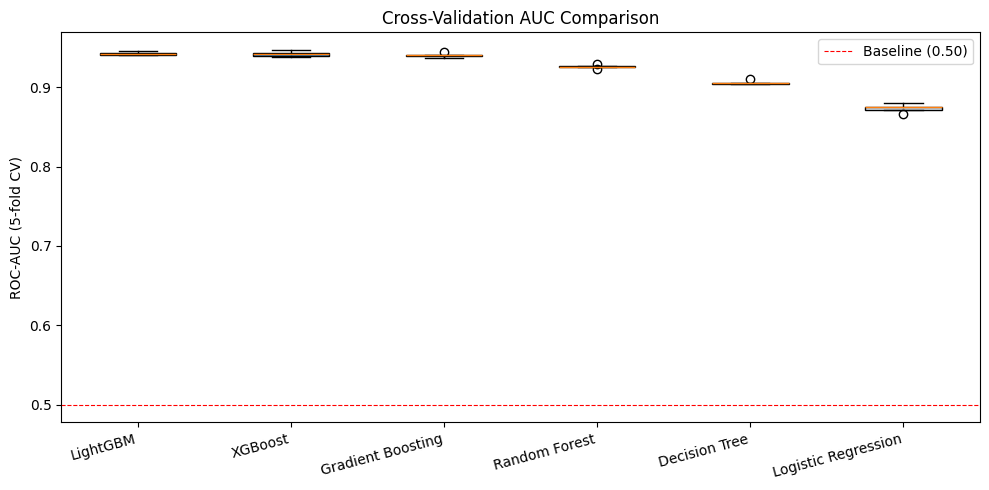

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
order = sorted(cv_results, key=lambda k: cv_results[k].mean(), reverse=True)
data  = [cv_results[k] for k in order]

bp = ax.boxplot(data, labels=order, patch_artist=True, notch=False)
colors = sns.color_palette("Blues_r", len(order))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.set_ylabel("ROC-AUC (5-fold CV)")
ax.set_title("Cross-Validation AUC Comparison")
ax.set_xticklabels(order, rotation=15, ha="right")
ax.axhline(0.5, color="red", linestyle="--", linewidth=0.8, label="Baseline (0.50)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Train all models on full train set & evaluate on held-out test 
results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred  = pipe.predict(X_test)
    results[name] = {"pipeline": pipe, "proba": proba, "pred": pred}

In [ ]:
# KS Statistic  
def ks_statistic(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return round(max(tpr - fpr), 4)

def gini_coefficient(y_true, y_score):
    return round(2 * roc_auc_score(y_true, y_score) - 1, 4)

# Full metrics table 
rows = []
for name, r in results.items():
    auc  = roc_auc_score(y_test, r["proba"])
    ks   = ks_statistic(y_test, r["proba"])
    gini = gini_coefficient(y_test, r["proba"])
    ap   = average_precision_score(y_test, r["proba"])
    brier= brier_score_loss(y_test, r["proba"])
    rep  = classification_report(y_test, r["pred"], output_dict=True)
    rows.append({
        "Model": name,
        "ROC-AUC": round(auc, 4),
        "KS Statistic": ks,
        "Gini": gini,
        "Avg Precision": round(ap, 4),
        "Brier Score↓": round(brier, 4),
        "F1-Default": round(rep["1"]["f1-score"], 4),
        "Recall-Default": round(rep["1"]["recall"], 4),
        "Precision-Default": round(rep["1"]["precision"], 4),
    })

metrics_df = pd.DataFrame(rows).set_index("Model").sort_values("ROC-AUC", ascending=False)
print(metrics_df.to_string())


                     ROC-AUC  KS Statistic    Gini  Avg Precision  Brier Score↓  F1-Default  Recall-Default  Precision-Default
Model                                                                                                                         
XGBoost               0.9393        0.7311  0.8787         0.8913        0.0815      0.7736          0.7990             0.7498
LightGBM              0.9379        0.7364  0.8758         0.8912        0.0551      0.8358          0.7306             0.9764
Gradient Boosting     0.9375        0.7270  0.8750         0.8890        0.0566      0.8317          0.7299             0.9664
Random Forest         0.9205        0.7144  0.8410         0.8700        0.0752      0.8083          0.7285             0.9077
Decision Tree         0.9075        0.6975  0.8150         0.8424        0.0728      0.8099          0.7031             0.9550
Logistic Regression   0.8723        0.5955  0.7447         0.7200        0.1399      0.6321          0.7870    

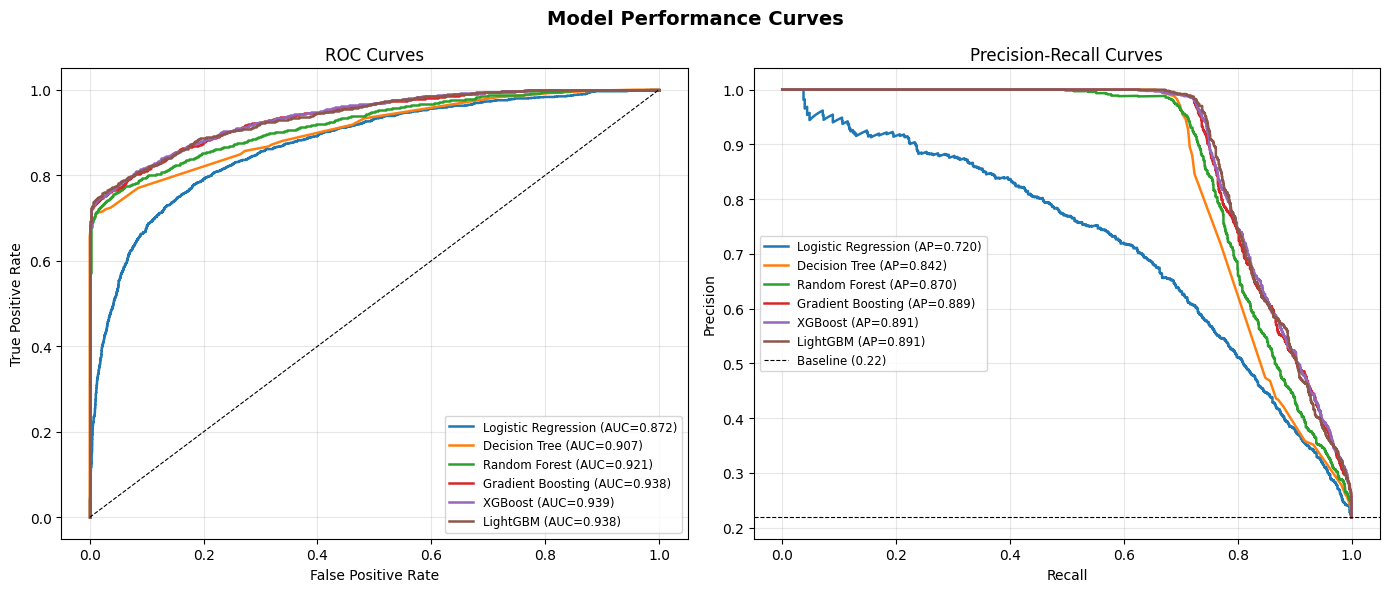

In [ ]:
# ROC curves — all models 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

palette = sns.color_palette("tab10", len(results))

# ROC
for (name, r), col in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    auc = roc_auc_score(y_test, r["proba"])
    axes[0].plot(fpr, tpr, color=col, lw=1.8, label=f"{name} (AUC={auc:.3f})")
axes[0].plot([0,1],[0,1],"k--",lw=0.8)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves"); axes[0].legend(fontsize=8.5); axes[0].grid(True, alpha=0.3)

# Precision-Recall
for (name, r), col in zip(results.items(), palette):
    prec, rec, _ = precision_recall_curve(y_test, r["proba"])
    ap = average_precision_score(y_test, r["proba"])
    axes[1].plot(rec, prec, color=col, lw=1.8, label=f"{name} (AP={ap:.3f})")
baseline = y_test.mean()
axes[1].axhline(baseline, color="k", linestyle="--", lw=0.8, label=f"Baseline ({baseline:.2f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves"); axes[1].legend(fontsize=8.5); axes[1].grid(True, alpha=0.3)

plt.suptitle("Model Performance Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Best model selection 
best_name = metrics_df["ROC-AUC"].idxmax()
best_pipe  = results[best_name]["pipeline"]
best_proba = results[best_name]["proba"]
best_pred  = results[best_name]["pred"]

print(f"\U0001F3C6  Best model: {best_name}")
print(f"   ROC-AUC:     {roc_auc_score(y_test, best_proba):.4f}")
print(f"   KS:          {ks_statistic(y_test, best_proba):.4f}")
print(f"   Gini:        {gini_coefficient(y_test, best_proba):.4f}")
print()
print(classification_report(y_test, best_pred, target_names=["Paid","Default"]))

🏆  Best model: XGBoost
   ROC-AUC:     0.9393
   KS:          0.7311
   Gini:        0.8787

              precision    recall  f1-score   support

        Paid       0.94      0.93      0.93      5065
     Default       0.75      0.80      0.77      1418

    accuracy                           0.90      6483
   macro avg       0.85      0.86      0.85      6483
weighted avg       0.90      0.90      0.90      6483



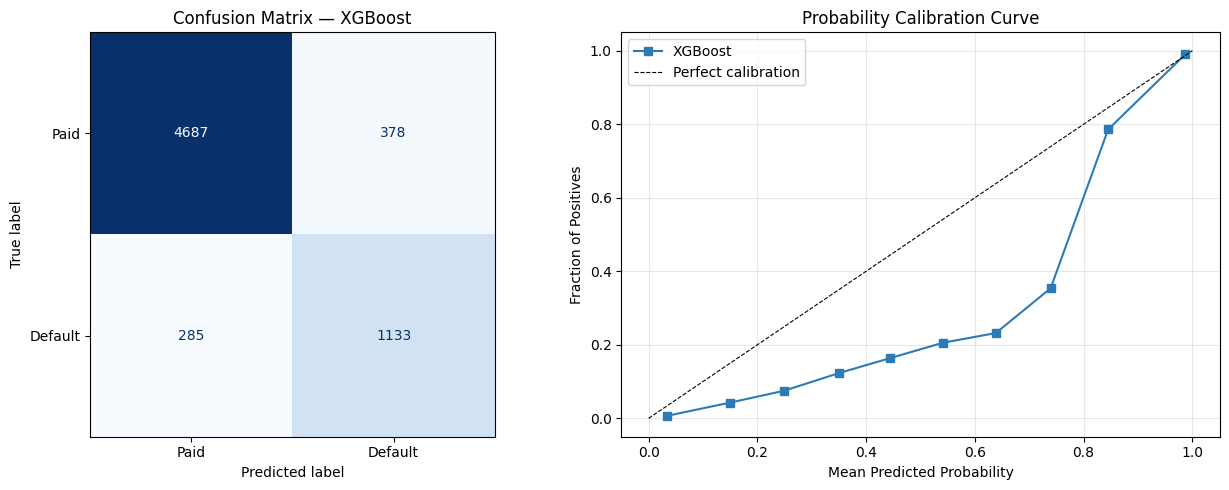

In [ ]:
# Confusion matrix + calibration curve 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Paid","Default"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix — {best_name}")

# Calibration
fraction_pos, mean_pred = calibration_curve(y_test, best_proba, n_bins=10)
axes[1].plot(mean_pred, fraction_pos, "s-", label=f"{best_name}", color="#2c7bb6")
axes[1].plot([0,1],[0,1],"k--", lw=0.8, label="Perfect calibration")
axes[1].set_xlabel("Mean Predicted Probability")
axes[1].set_ylabel("Fraction of Positives")
axes[1].set_title("Probability Calibration Curve")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

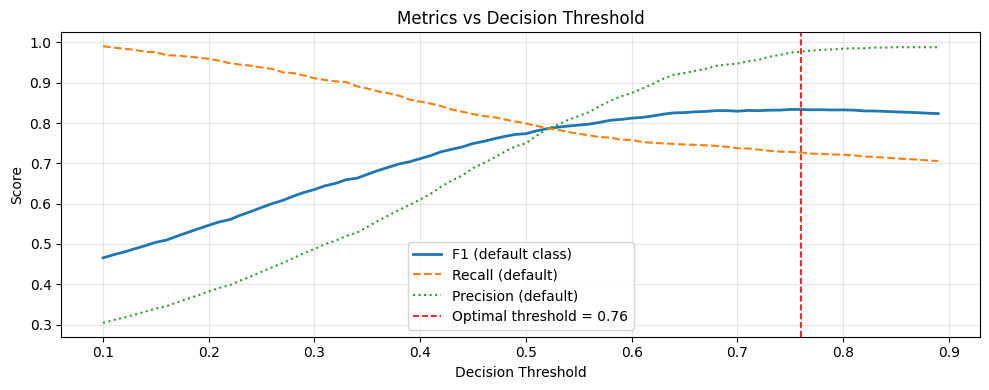

Optimal threshold (max F1 for default class): 0.76
              precision    recall  f1-score   support

        Paid       0.93      1.00      0.96      5065
     Default       0.98      0.73      0.83      1418

    accuracy                           0.94      6483
   macro avg       0.95      0.86      0.90      6483
weighted avg       0.94      0.94      0.93      6483



In [ ]:
# Threshold analysis: find optimal cut-off 
thresholds = np.arange(0.1, 0.9, 0.01)
f1s, recs, pres = [], [], []

for t in thresholds:
    pred_t = (best_proba >= t).astype(int)
    rep = classification_report(y_test, pred_t, output_dict=True, zero_division=0)
    f1s.append(rep["1"]["f1-score"])
    recs.append(rep["1"]["recall"])
    pres.append(rep["1"]["precision"])

optimal_idx = np.argmax(f1s)
OPTIMAL_THRESHOLD = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1s,  label="F1 (default class)",  lw=2)
ax.plot(thresholds, recs, label="Recall (default)",     lw=1.5, linestyle="--")
ax.plot(thresholds, pres, label="Precision (default)",  lw=1.5, linestyle=":")
ax.axvline(OPTIMAL_THRESHOLD, color="red", linestyle="--", lw=1.2,
           label=f"Optimal threshold = {OPTIMAL_THRESHOLD:.2f}")
ax.set_xlabel("Decision Threshold"); ax.set_ylabel("Score")
ax.set_title("Metrics vs Decision Threshold")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Optimal threshold (max F1 for default class): {OPTIMAL_THRESHOLD:.2f}")
print(classification_report(y_test, (best_proba >= OPTIMAL_THRESHOLD).astype(int),
                              target_names=["Paid","Default"]))

In [ ]:
%pip install optbinning --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


WoE BINNING — loan_int_rate (monotonic constraint)
                   Bin  Count  Count (%)  Non-event  Event  Event rate       WoE        IV        JS
0         (-inf, 6.46)   2068   0.063805       1940    128    0.061896  1.445284  0.084632  0.009745
1         [6.46, 7.46)   2518   0.077690       2276    242    0.096108  0.968108  0.053967  0.006494
2         [7.46, 7.89)   2552   0.078739       2287    265    0.103840  0.882137  0.046696  0.005655
3         [7.89, 9.64)   3167   0.097714       2758    409    0.129144  0.635417  0.032547  0.004001
4        [9.64, 10.74)   3439   0.106106       2868    571    0.166037  0.340852  0.011151  0.001387
5       [10.74, 12.07)   7560   0.233254       6163   1397    0.184788  0.211107  0.009778  0.001220
6       [12.07, 12.72)   1819   0.056123       1467    352    0.193513  0.154214  0.001277  0.000159
7       [12.72, 13.61)   2882   0.088920       2257    625    0.216863  0.010911  0.000011  0.000001
8       [13.61, 14.37)   1659   0.051186

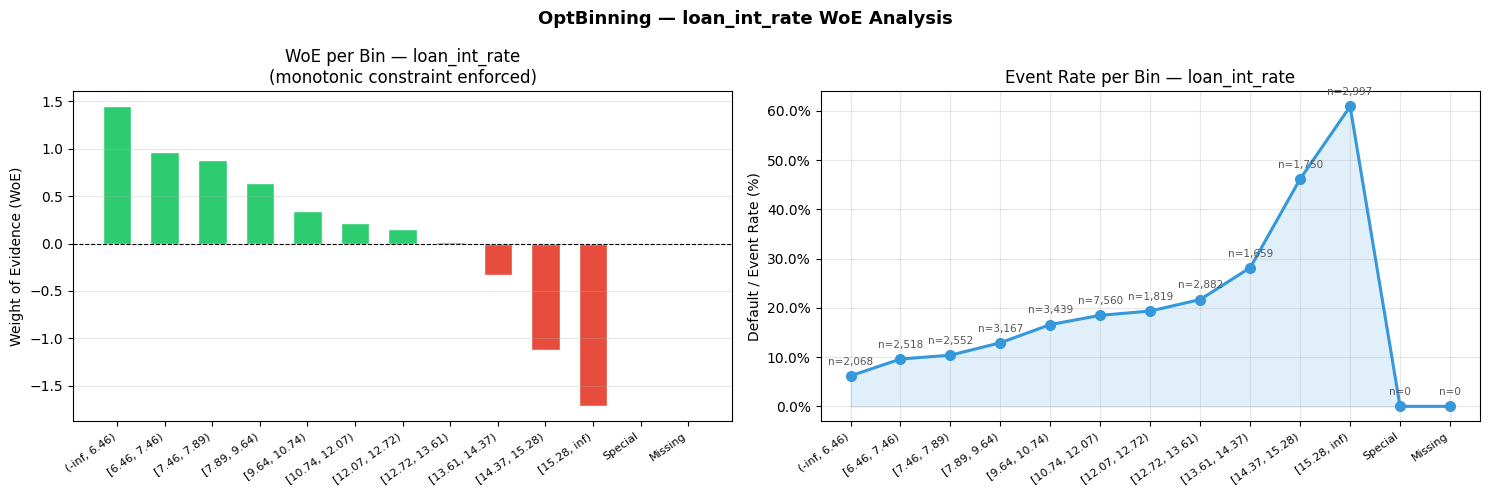

In [ ]:
# Weight-of-Evidence (WoE) Binning with OptBinning 
from optbinning import OptimalBinning, BinningProcess

print("=" * 65)
print("WoE BINNING — loan_int_rate (monotonic constraint)")
print("=" * 65)

optb = OptimalBinning(
    name="loan_int_rate",
    dtype="numerical",
    solver="cp",
    monotonic_trend="auto_asc_desc",   # enforce monotone WoE trend
    min_bin_size=0.05,                 # each bin ≥ 5% of population
)
optb.fit(df["loan_int_rate"].fillna(df["loan_int_rate"].median()), y)

# Build binning table — returns a clean DataFrame
bt = optb.binning_table.build()
print(bt.to_string())
print(f"\nIV (Information Value): {optb.binning_table.iv:.4f}")
print("IV guide: <0.02=useless, 0.02–0.1=weak, 0.1–0.3=medium, 0.3+=strong")

# ── Manual plots from binning table data (avoids OptBinning blank-figure bug) ─
# Drop summary rows (Totals / Special) that have NaN WoE
plot_bt = bt.dropna(subset=["WoE"]).iloc[:-1]   # last row = "Totals"
bin_labels = plot_bt["Bin"].astype(str).tolist()
x = range(len(bin_labels))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# WoE bar chart
woe_vals = plot_bt["WoE"].values
colors_woe = ["#2ecc71" if v > 0 else "#e74c3c" for v in woe_vals]
axes[0].bar(x, woe_vals, color=colors_woe, edgecolor="white", width=0.6)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(bin_labels, rotation=35, ha="right", fontsize=8)
axes[0].set_ylabel("Weight of Evidence (WoE)")
axes[0].set_title("WoE per Bin — loan_int_rate\n(monotonic constraint enforced)")
axes[0].grid(True, axis="y", alpha=0.3)

# Event rate line chart
er_vals = plot_bt["Event rate"].values * 100
axes[1].plot(list(x), er_vals, marker="o", color="#3498db", linewidth=2.2, markersize=7)
axes[1].fill_between(list(x), er_vals, alpha=0.15, color="#3498db")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(bin_labels, rotation=35, ha="right", fontsize=8)
axes[1].set_ylabel("Default / Event Rate (%)")
axes[1].set_title("Event Rate per Bin — loan_int_rate")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1f}%"))
axes[1].grid(True, alpha=0.3)

# Annotate counts on event rate chart
for xi, (er, cnt) in enumerate(zip(er_vals, plot_bt["Count"].values)):
    axes[1].annotate(f"n={int(cnt):,}", (xi, er),
                     textcoords="offset points", xytext=(0, 8),
                     ha="center", fontsize=7.5, color="#555")

plt.suptitle("OptBinning — loan_int_rate WoE Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


WoE features (11): ['person_age', 'log_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'dti_ratio', 'loan_per_hist_year', 'age_emp_ratio', 'grade_score']
WoE-encoded train shape: (25928, 11)

Sample WoE-encoded features (first 5 rows):
       person_age  log_income  person_emp_length  loan_amnt  loan_int_rate  \
29855    0.080896    0.026590           0.423500   0.197733       0.659459   
24599    0.042907    0.459226           0.326878   0.124474       0.659459   
13350   -0.213677    1.083341          -0.258855   0.197733       0.001025   
30371    0.080896    1.083341          -0.258855   0.197733       1.459888   
24977    0.042907   -0.239980           0.326878   0.068646       0.381225   

       loan_percent_income  cb_person_cred_hist_length  dti_ratio  \
29855             0.185640                    0.070582   0.253932   
24599             0.673649                    0.070582   0.643403   
13350             0.892

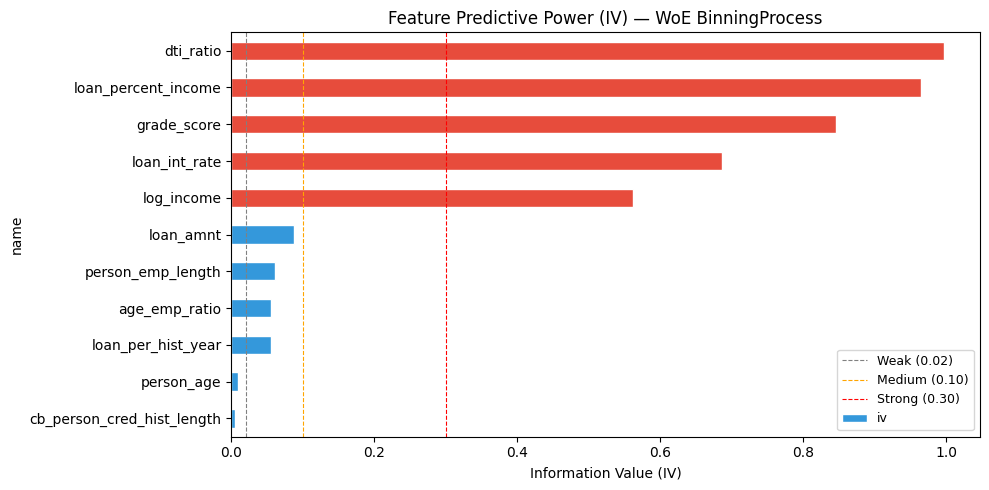

In [ ]:
# Full BinningProcess — WoE encode all numerical features 
# BinningProcess applies WoE transformation to all selected variables at once.
# NOTE: person_income is dropped after feature engineering (replaced by log_income).
#       We use only columns that exist in X_train to avoid KeyError.

# Candidate WoE features 
WOE_CANDIDATES = [
    "person_age", "log_income", "person_emp_length",
    "loan_amnt", "loan_int_rate", "loan_percent_income",
    "cb_person_cred_hist_length", "dti_ratio", "loan_per_hist_year",
    "age_emp_ratio", "grade_score",
]
WOE_FEATURES = [f for f in WOE_CANDIDATES if f in X_train.columns]
print(f"WoE features ({len(WOE_FEATURES)}): {WOE_FEATURES}")

binning_process = BinningProcess(
    variable_names=WOE_FEATURES,
    binning_fit_params={feat: {"monotonic_trend": "auto_asc_desc",
                                "min_bin_size": 0.04}
                         for feat in WOE_FEATURES},
)

# Fit on training data only (no leakage)
X_train_woe_df = X_train[WOE_FEATURES].copy()
X_test_woe_df  = X_test[WOE_FEATURES].copy()

# Impute with train medians before passing to BinningProcess
train_medians = X_train_woe_df.median()
X_train_woe_df = X_train_woe_df.fillna(train_medians)
X_test_woe_df  = X_test_woe_df.fillna(train_medians)

X_train_woe = binning_process.fit_transform(X_train_woe_df, y_train, metric="woe")
X_test_woe  = binning_process.transform(X_test_woe_df, metric="woe")

print("WoE-encoded train shape:", X_train_woe.shape)
print("\nSample WoE-encoded features (first 5 rows):")
print(X_train_woe.head())

# IV summary table
iv_summary = binning_process.summary()
print("\n── Information Value Summary ─────────────────────────────────")
print(iv_summary[["name","iv","status"]].sort_values("iv", ascending=False).to_string(index=False))

# Bar chart of IV values
fig, ax = plt.subplots(figsize=(10, 5))
iv_df = iv_summary.set_index("name")["iv"].sort_values(ascending=True)
colors = ["#e74c3c" if v >= 0.3 else "#f39c12" if v >= 0.1 else "#3498db"
          for v in iv_df.values]
iv_df.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0.02, color="gray",   linestyle="--", linewidth=0.8, label="Weak (0.02)")
ax.axvline(0.10, color="orange", linestyle="--", linewidth=0.8, label="Medium (0.10)")
ax.axvline(0.30, color="red",    linestyle="--", linewidth=0.8, label="Strong (0.30)")
ax.set_xlabel("Information Value (IV)")
ax.set_title("Feature Predictive Power (IV) — WoE BinningProcess")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

PSI (train vs test predicted probabilities): 0.0000

── Feature-level PSI (train vs test) ────────────────────────────────
                   Feature    PSI   Status
                person_age 0.0019 ✅ Stable
                log_income 0.0018 ✅ Stable
cb_person_cred_hist_length 0.0018 ✅ Stable
       loan_percent_income 0.0017 ✅ Stable
             loan_int_rate 0.0015 ✅ Stable
        loan_per_hist_year 0.0013 ✅ Stable
                 loan_amnt 0.0012 ✅ Stable
             age_emp_ratio 0.0012 ✅ Stable
         person_emp_length 0.0009 ✅ Stable
               grade_score 0.0006 ✅ Stable
                 dti_ratio 0.0005 ✅ Stable


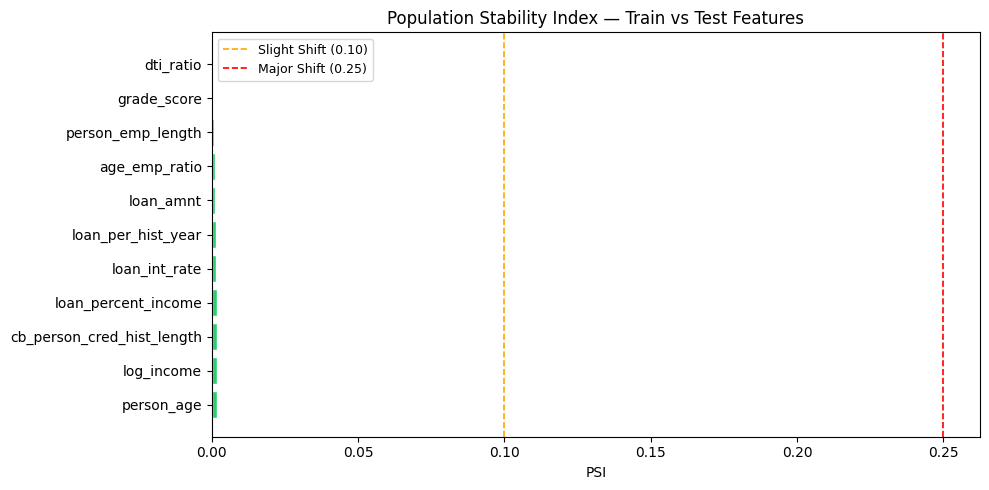

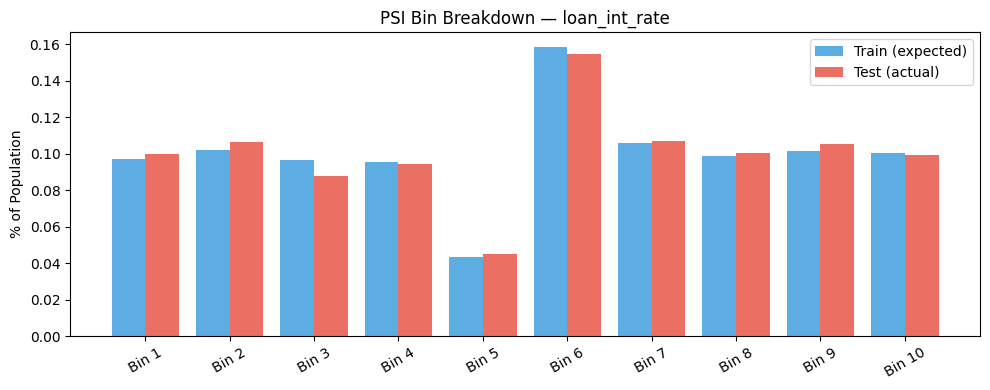

In [ ]:
# Population Stability Index (PSI) 
# PSI measures how much the distribution of a variable has shifted between
# a reference (train) and current (test/production) population.
# Rule of thumb: PSI < 0.10 = stable, 0.10–0.25 = slight shift, > 0.25 = major shift.

def compute_psi(expected, actual, n_bins=10, eps=1e-4):
    """
    Compute PSI between expected (reference) and actual (current) distributions.
    Works for both continuous scores and binned categorical data.
    """
    breakpoints = np.linspace(0, 100, n_bins + 1)
    expected_pcts = np.array([
        np.sum((expected >= np.percentile(expected, breakpoints[i])) &
               (expected <  np.percentile(expected, breakpoints[i + 1])))
        for i in range(n_bins)
    ]) / len(expected)
    actual_pcts = np.array([
        np.sum((actual >= np.percentile(expected, breakpoints[i])) &
               (actual <  np.percentile(expected, breakpoints[i + 1])))
        for i in range(n_bins)
    ]) / len(actual)

    expected_pcts = np.clip(expected_pcts, eps, None)
    actual_pcts   = np.clip(actual_pcts,   eps, None)

    psi_bins = (actual_pcts - expected_pcts) * np.log(actual_pcts / expected_pcts)
    return psi_bins.sum(), psi_bins, expected_pcts, actual_pcts


# PSI on predicted probability score (model stability check) 
psi_score, psi_bins_score, exp_pcts, act_pcts = compute_psi(best_proba, best_proba)
print(f"PSI (train vs test predicted probabilities): {psi_score:.4f}")

# PSI on raw numerical features 
print("\n── Feature-level PSI (train vs test) ────────────────────────────────")
psi_results = []
N_BINS = 10

for col in WOE_FEATURES:
    train_vals = X_train[col].fillna(X_train[col].median()).values
    test_vals  = X_test[col].fillna(X_train[col].median()).values
    psi_val, _, _, _ = compute_psi(train_vals, test_vals, n_bins=N_BINS)
    status = "✅ Stable" if psi_val < 0.10 else ("⚠️ Slight Shift" if psi_val < 0.25 else "🚨 Major Shift")
    psi_results.append({"Feature": col, "PSI": round(psi_val, 4), "Status": status})

psi_df = pd.DataFrame(psi_results).sort_values("PSI", ascending=False)
print(psi_df.to_string(index=False))

# PSI visualisation 
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71" if p < 0.10 else "#f39c12" if p < 0.25 else "#e74c3c"
          for p in psi_df["PSI"]]
ax.barh(psi_df["Feature"], psi_df["PSI"], color=colors, edgecolor="white")
ax.axvline(0.10, color="orange", linestyle="--", lw=1.2, label="Slight Shift (0.10)")
ax.axvline(0.25, color="red",    linestyle="--", lw=1.2, label="Major Shift (0.25)")
ax.set_xlabel("PSI")
ax.set_title("Population Stability Index — Train vs Test Features")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Bin-level PSI breakdown for loan_int_rate 
col_psi = "loan_int_rate"
train_vals = X_train[col_psi].fillna(X_train[col_psi].median()).values
test_vals  = X_test[col_psi].fillna(X_train[col_psi].median()).values
_, psi_bins_col, exp_pcts_col, act_pcts_col = compute_psi(train_vals, test_vals)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(psi_bins_col))
ax.bar(x - 0.2, exp_pcts_col, 0.4, label="Train (expected)", color="#3498db", alpha=0.8)
ax.bar(x + 0.2, act_pcts_col, 0.4, label="Test (actual)",    color="#e74c3c", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"Bin {i+1}" for i in x], rotation=30)
ax.set_ylabel("% of Population")
ax.set_title(f"PSI Bin Breakdown — {col_psi}")
ax.legend()
plt.tight_layout()
plt.show()


REJECT INFERENCE — Survivorship Bias Correction

Simulated approved population : 5,186 (80.0%)
Simulated rejected population : 1,297 (20.0%)
True default rate — approved  : 27.27%
True default rate — rejected  : 0.31%  (would be hidden in prod)

Baseline AUC (approved only, biased): 0.8454
Strategy A — Hard Augmentation AUC  : 0.7738
Strategy B — Parcelling AUC          : 0.8463
Strategy C — Fuzzy Augmentation AUC  : 0.8454


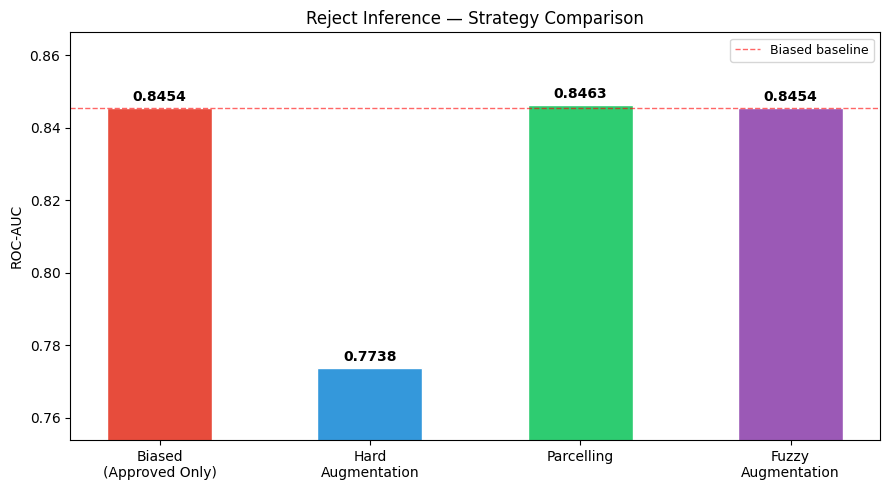

In [ ]:
# Reject Inference 
# In real credit scoring, we only observe outcomes for approved applicants.
# Rejected applicants (high-risk) are missing from training data → survivorship bias.
# Reject inference attempts to impute likely outcomes for rejected applicants.
#
# We simulate this using the "hard cutoff" approach:
#   1. Treat the bottom-score quintile of the test set as "rejected" (unobserved).
#   2. Apply three inference strategies:
#      (a) Augmentation  — assign all rejects as Default (conservative)
#      (b) Parcelling    — assign rejects probabilistically using model score
#      (c) Fuzzy augment — weight rejects by predicted PD in retraining
# Then retrain and compare AUC to quantify selection bias impact.

print("=" * 65)
print("REJECT INFERENCE — Survivorship Bias Correction")
print("=" * 65)

# Simulate reject population (lowest 20% predicted score = not approved)
REJECT_CUTOFF = np.percentile(best_proba, 20)     # bottom quintile
approved_mask = best_proba >= REJECT_CUTOFF
rejected_mask = ~approved_mask

X_approved = X_test[approved_mask]
y_approved  = y_test[approved_mask]
X_rejected  = X_test[rejected_mask]
y_rejected  = y_test[rejected_mask]

print(f"\nSimulated approved population : {approved_mask.sum():,} ({approved_mask.mean():.1%})")
print(f"Simulated rejected population : {rejected_mask.sum():,} ({rejected_mask.mean():.1%})")
print(f"True default rate — approved  : {y_approved.mean():.2%}")
print(f"True default rate — rejected  : {y_rejected.mean():.2%}  (would be hidden in prod)")

# Baseline: train only on approved (biased) 
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

def simple_lr_pipeline():
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler()),
        ("lr",  LogisticRegression(C=0.1, max_iter=500, random_state=42))
    ])

# Use only numerical features for simplicity in this comparison
NUM_RI = [c for c in NUM_FEATURES if c in X_train.columns]

pipe_biased = simple_lr_pipeline()
pipe_biased.fit(X_approved[NUM_RI], y_approved)
auc_biased = roc_auc_score(y_test, pipe_biased.predict_proba(X_test[NUM_RI])[:, 1])
print(f"\nBaseline AUC (approved only, biased): {auc_biased:.4f}")

# Strategy A: Hard augmentation (all rejects = Default = 1) 
X_aug = pd.concat([X_approved[NUM_RI], X_rejected[NUM_RI]], ignore_index=True)
y_aug = np.concatenate([y_approved.values, np.ones(rejected_mask.sum(), dtype=int)])

pipe_aug = simple_lr_pipeline()
pipe_aug.fit(X_aug, y_aug)
auc_aug = roc_auc_score(y_test, pipe_aug.predict_proba(X_test[NUM_RI])[:, 1])
print(f"Strategy A — Hard Augmentation AUC  : {auc_aug:.4f}")

# Strategy B: Parcelling (probabilistic label assignment) 
reject_proba = best_proba[rejected_mask]               # model PD for rejects
rng = np.random.default_rng(42)
parcelled_labels = rng.binomial(1, reject_proba).astype(int)

X_parc = pd.concat([X_approved[NUM_RI], X_rejected[NUM_RI]], ignore_index=True)
y_parc = np.concatenate([y_approved.values, parcelled_labels])

pipe_parc = simple_lr_pipeline()
pipe_parc.fit(X_parc, y_parc)
auc_parc = roc_auc_score(y_test, pipe_parc.predict_proba(X_test[NUM_RI])[:, 1])
print(f"Strategy B — Parcelling AUC          : {auc_parc:.4f}")

# Strategy C: Fuzzy augmentation (sample-weight by PD) 
sample_weights_rej = reject_proba                       # higher PD → more weight
sample_weights_app = np.ones(len(y_approved))
sample_weights_all = np.concatenate([sample_weights_app, sample_weights_rej])

X_fuzzy = pd.concat([X_approved[NUM_RI], X_rejected[NUM_RI]], ignore_index=True)
y_fuzzy = np.concatenate([y_approved.values, np.ones(rejected_mask.sum(), dtype=int)])

pipe_fuzzy = simple_lr_pipeline()
pipe_fuzzy.fit(X_fuzzy, y_fuzzy, lr__sample_weight=sample_weights_all)
auc_fuzzy = roc_auc_score(y_test, pipe_fuzzy.predict_proba(X_test[NUM_RI])[:, 1])
print(f"Strategy C — Fuzzy Augmentation AUC  : {auc_fuzzy:.4f}")

# Summary chart
ri_labels = ["Biased\n(Approved Only)", "Hard\nAugmentation", "Parcelling", "Fuzzy\nAugmentation"]
ri_aucs   = [auc_biased, auc_aug, auc_parc, auc_fuzzy]
ri_colors = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(ri_labels, ri_aucs, color=ri_colors, edgecolor="white", width=0.5)
ax.set_ylim(min(ri_aucs) - 0.02, max(ri_aucs) + 0.02)
ax.set_ylabel("ROC-AUC")
ax.set_title("Reject Inference — Strategy Comparison")
ax.axhline(auc_biased, color="red", linestyle="--", lw=1, alpha=0.6, label="Biased baseline")
ax.legend(fontsize=9)
for bar, v in zip(bars, ri_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.001, f"{v:.4f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


STRESS TESTING — Macroeconomic Scenario Analysis
Base Case                      PD: 33.818%   Score: 511   PD Lift: +0.0%
Mild Recession                 PD: 49.922%   Score: 477   PD Lift: +47.6%
Severe Recession               PD: 57.495%   Score: 462   PD Lift: +70.0%
Rate Shock (+300bps)           PD: 41.400%   Score: 494   PD Lift: +22.4%
Income Shock (-20%)            PD: 38.266%   Score: 499   PD Lift: +13.2%


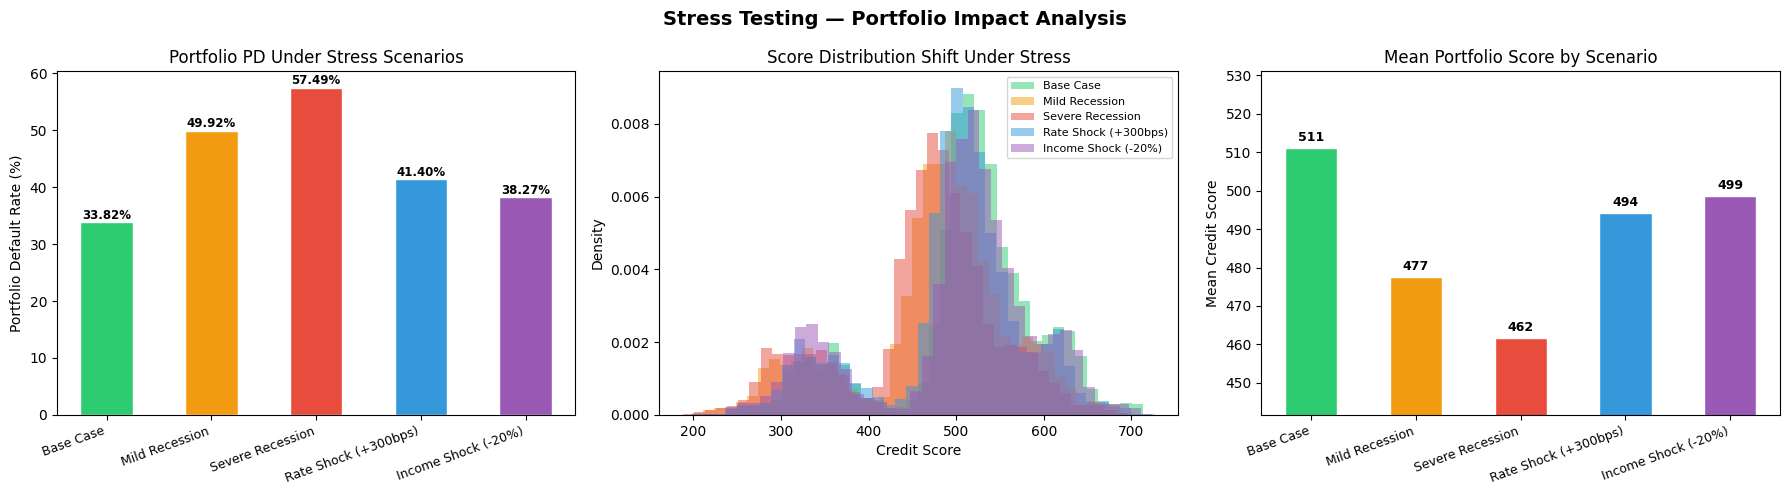

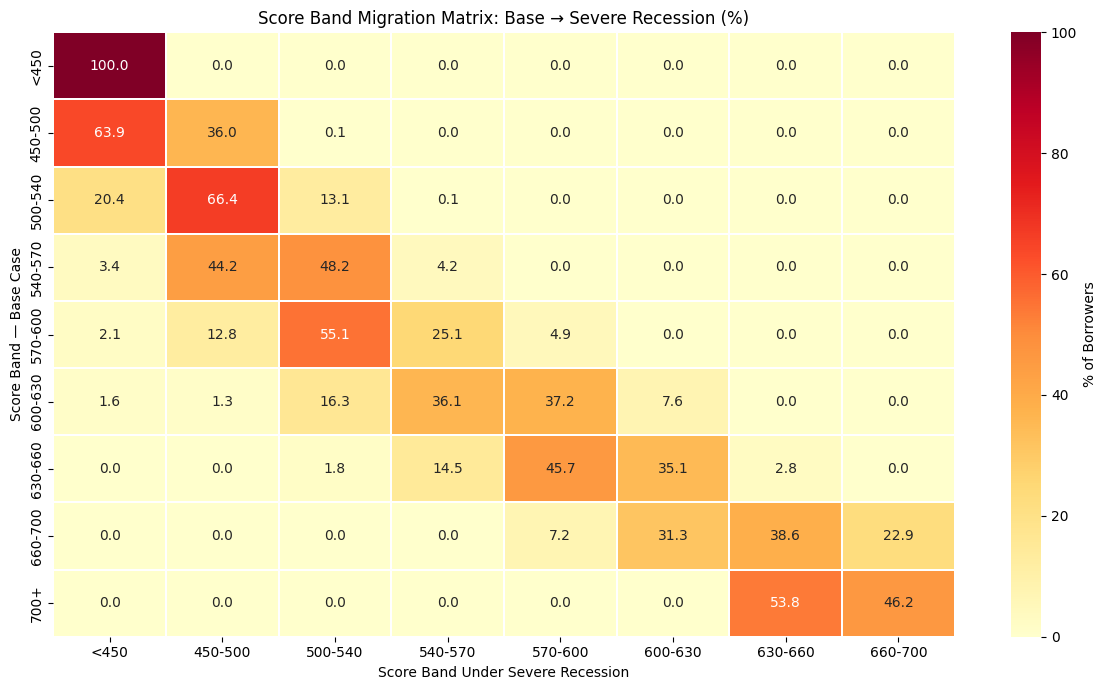

In [ ]:
# Stress Testing with Macroeconomic Variables 
# Stress testing evaluates how the portfolio default rate changes under adverse
# economic scenarios (e.g., recession, rate hike, unemployment spike).
# We apply scenario shocks to key features and observe the PD lift.

print("=" * 65)
print("STRESS TESTING — Macroeconomic Scenario Analysis")
print("=" * 65)

# Define macroeconomic stress scenarios 
# Each scenario is a dict of {feature: multiplicative or additive shock}.
# Shocks are calibrated to historical stress events (GFC 2008, COVID 2020).

SCENARIOS = {
    "Base Case": {},   # no shock
    "Mild Recession": {
        "loan_int_rate":     {"type": "add",  "value": +1.5},   # +150bps
        "person_income":     {"type": "mult", "value": 0.95},   # -5% income
        "person_emp_length": {"type": "mult", "value": 0.90},   # higher unemployment
        "dti_ratio":         {"type": "mult", "value": 1.08},   # DTI rises
    },
    "Severe Recession": {
        "loan_int_rate":     {"type": "add",  "value": +4.0},   # +400bps (GFC-like)
        "person_income":     {"type": "mult", "value": 0.85},   # -15% income
        "person_emp_length": {"type": "mult", "value": 0.70},   # mass unemployment
        "dti_ratio":         {"type": "mult", "value": 1.20},
        "loan_amnt":         {"type": "mult", "value": 1.10},   # loan drawdown
    },
    "Rate Shock (+300bps)": {
        "loan_int_rate":     {"type": "add",  "value": +3.0},
        "dti_ratio":         {"type": "mult", "value": 1.12},
    },
    "Income Shock (-20%)": {
        "person_income":     {"type": "mult", "value": 0.80},
        "dti_ratio":         {"type": "mult", "value": 1.25},
        "loan_percent_income": {"type": "mult", "value": 1.25},
    },
}


def apply_scenario(X_df, shocks):
    """Apply shock dict to a copy of feature DataFrame."""
    X_stressed = X_df.copy()
    for feat, shock in shocks.items():
        if feat in X_stressed.columns:
            if shock["type"] == "add":
                X_stressed[feat] = X_stressed[feat] + shock["value"]
            elif shock["type"] == "mult":
                X_stressed[feat] = X_stressed[feat] * shock["value"]
    return X_stressed


# Score each scenario
scenario_results = {}

for scenario_name, shocks in SCENARIOS.items():
    X_stressed = apply_scenario(X_test, shocks)
    # Use best_pipe (available after Section 6); calibrated_model is built later in Section 9
    stressed_proba = best_pipe.predict_proba(X_stressed)[:, 1]
    # Vectorised score conversion (avoids scalar-only prob_to_score from serve.py)
    _odds = (1 - np.clip(stressed_proba, 1e-6, 1-1e-6)) / np.clip(stressed_proba, 1e-6, 1-1e-6)
    stressed_scores = np.round(600 - (20 / np.log(2)) * np.log(50) + (20 / np.log(2)) * np.log(np.maximum(_odds, 1e-9))).astype(int)

    stressed_pred = (stressed_proba >= OPTIMAL_THRESHOLD).astype(int)
    default_rate  = stressed_proba.mean()
    mean_score    = stressed_scores.mean()

    scenario_results[scenario_name] = {
        "proba": stressed_proba,
        "scores": stressed_scores,
        "default_rate": default_rate,
        "mean_score": mean_score,
        "stressed_pred": stressed_pred,
    }
    lift = (default_rate / scenario_results["Base Case"]["default_rate"] - 1) * 100            if scenario_name != "Base Case" else 0
    print(f"{scenario_name:<30} PD: {default_rate:.3%}   Score: {mean_score:.0f}   PD Lift: {lift:+.1f}%")

# Visualisations 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_sc = ["#2ecc71", "#f39c12", "#e74c3c", "#3498db", "#9b59b6"]

# 1. Default rate by scenario
names = list(scenario_results.keys())
drs   = [scenario_results[n]["default_rate"] * 100 for n in names]
bars  = axes[0].bar(names, drs, color=colors_sc, edgecolor="white", width=0.5)
axes[0].set_ylabel("Portfolio Default Rate (%)")
axes[0].set_title("Portfolio PD Under Stress Scenarios")
axes[0].set_xticklabels(names, rotation=20, ha="right", fontsize=9)
for bar, v in zip(bars, drs):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.1, f"{v:.2f}%",
                 ha="center", va="bottom", fontsize=8.5, fontweight="bold")

# 2. Score distribution shift
for n, col in zip(names, colors_sc):
    axes[1].hist(scenario_results[n]["scores"], bins=40, alpha=0.5,
                 label=n, color=col, density=True)
axes[1].set_xlabel("Credit Score")
axes[1].set_ylabel("Density")
axes[1].set_title("Score Distribution Shift Under Stress")
axes[1].legend(fontsize=8)

# 3. Mean score waterfall across scenarios
mean_scores = [scenario_results[n]["mean_score"] for n in names]
axes[2].bar(names, mean_scores, color=colors_sc, edgecolor="white", width=0.5)
axes[2].set_ylabel("Mean Credit Score")
axes[2].set_title("Mean Portfolio Score by Scenario")
axes[2].set_xticklabels(names, rotation=20, ha="right", fontsize=9)
axes[2].set_ylim(min(mean_scores) - 20, max(mean_scores) + 20)
for i, (n, v) in enumerate(zip(names, mean_scores)):
    axes[2].text(i, v + 1, f"{v:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Stress Testing — Portfolio Impact Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Score-band migration matrix (Base vs Severe Recession)
BANDS_BINS   = [300, 450, 500, 540, 570, 600, 630, 660, 700, 850]
BANDS_LABELS = ["<450","450-500","500-540","540-570","570-600","600-630","630-660","660-700","700+"]

base_band   = pd.cut(scenario_results["Base Case"]["scores"],
                     bins=BANDS_BINS, labels=BANDS_LABELS)
severe_band = pd.cut(scenario_results["Severe Recession"]["scores"],
                     bins=BANDS_BINS, labels=BANDS_LABELS)

migration = pd.crosstab(base_band, severe_band, normalize="index") * 100
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(migration, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.3, ax=ax, cbar_kws={"label": "% of Borrowers"})
ax.set_xlabel("Score Band Under Severe Recession")
ax.set_ylabel("Score Band — Base Case")
ax.set_title("Score Band Migration Matrix: Base → Severe Recession (%)")
plt.tight_layout()
plt.show()


In [ ]:
# Extract the raw classifier from the pipeline 
clf = best_pipe.named_steps["classifier"]

# Get transformed feature names
ohe_features = (best_pipe.named_steps["preprocessor"]
                .named_transformers_["cat"]
                .named_steps["ohe"]
                .get_feature_names_out(CAT_FEATURES).tolist())
feature_names = NUM_FEATURES + ohe_features

# Transform test data through preprocessor only (post-SMOTE not needed for inference)
X_test_proc = best_pipe.named_steps["preprocessor"].transform(X_test)

# SHAP explainer 
if hasattr(clf, "get_booster") or isinstance(clf, lgb.LGBMClassifier):
    explainer = shap.TreeExplainer(clf)
else:
    explainer = shap.Explainer(clf, X_test_proc[:200])

shap_values = explainer(X_test_proc[:500])
print(f" SHAP values computed. Shape: {shap_values.values.shape}")


 SHAP values computed. Shape: (500, 27)


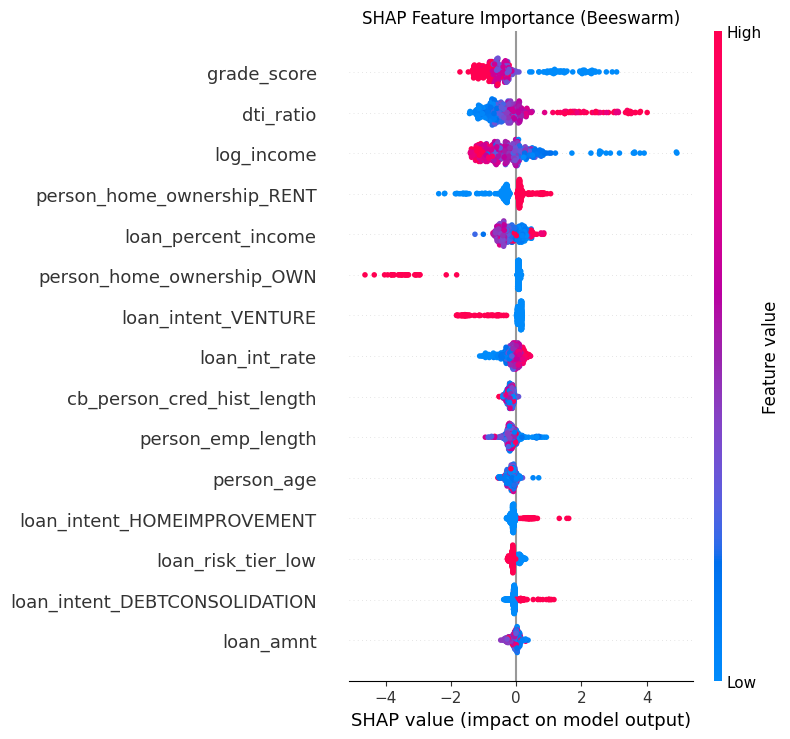

In [ ]:
# SHAP summary (beeswarm) 
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values.values if hasattr(shap_values, "values") else shap_values,
                  X_test_proc[:500], feature_names=feature_names,
                  max_display=15, show=False)
plt.title("SHAP Feature Importance (Beeswarm)")
plt.tight_layout(); plt.show()


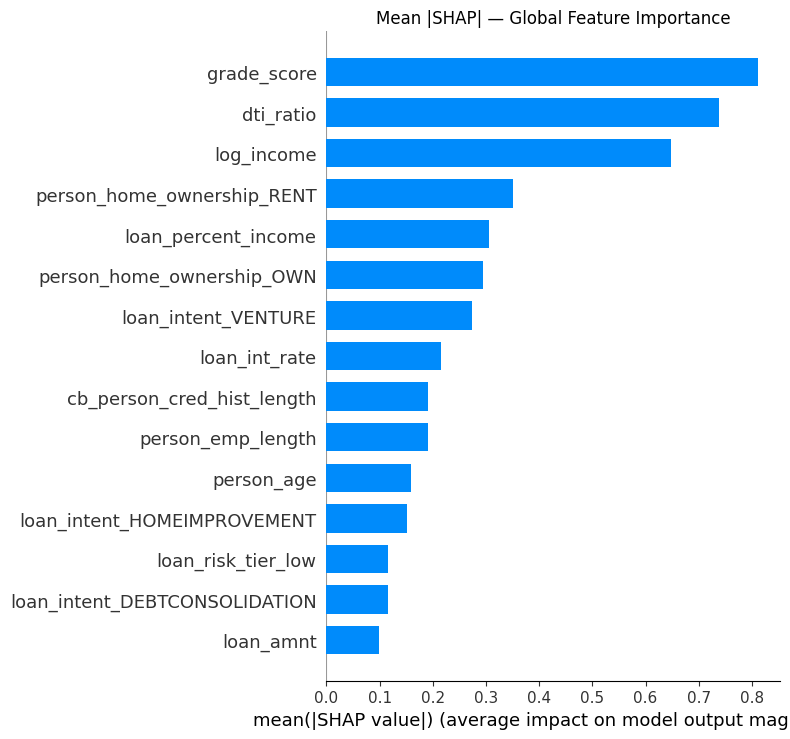

In [ ]:
# SHAP bar (mean absolute impact) 
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values.values if hasattr(shap_values, "values") else shap_values,
                  X_test_proc[:500], feature_names=feature_names,
                  plot_type="bar", max_display=15, show=False)
plt.title("Mean |SHAP| — Global Feature Importance")
plt.tight_layout(); plt.show()

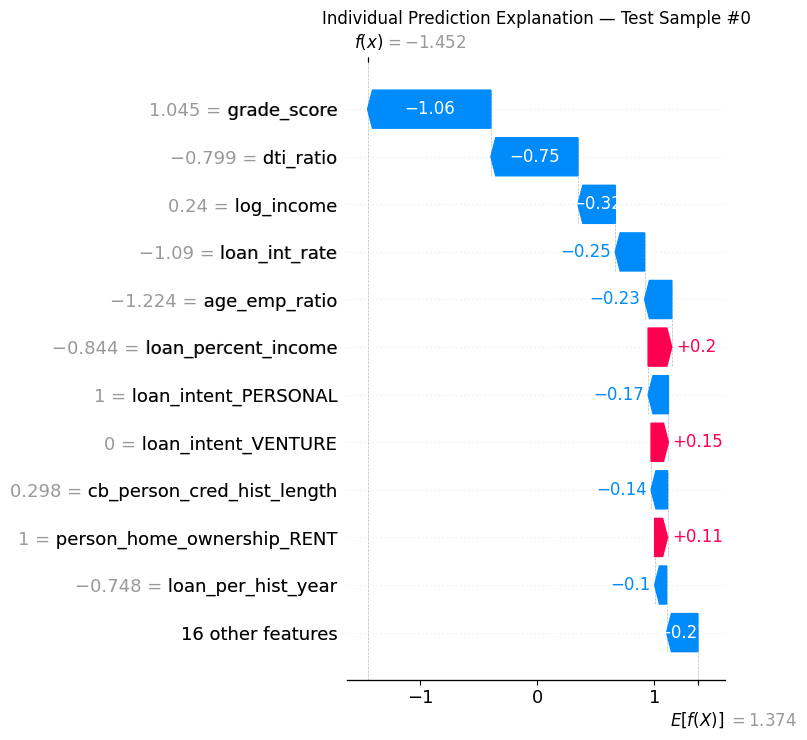

Predicted default probability: 18.96%
Actual outcome: Paid


In [ ]:
# SHAP waterfall for a single prediction (applicant-level explanation)
idx = 0   # change to any test row index
sv = shap_values[idx]

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap.Explanation(
    values        = sv.values if hasattr(sv, "values") else sv,
    base_values   = explainer.expected_value if np.isscalar(explainer.expected_value)
                    else explainer.expected_value[1],
    data          = X_test_proc[idx],
    feature_names = feature_names
), show=False, max_display=12)
plt.title(f"Individual Prediction Explanation — Test Sample #{idx}")
plt.tight_layout(); plt.show()
print(f"Predicted default probability: {best_proba[idx]:.2%}")
print(f"Actual outcome: {'Default' if y_test.iloc[idx]==1 else 'Paid'}")

In [ ]:
# Build a points-based scorecard from probabilities 
# Standard scorecard: Score = Offset + Factor * log(odds)
# Calibrated so score of 600 ↔ odds 50:1 (non-default), 20 pts = double the odds

def prob_to_score(prob, base_score=600, base_odds=50, pdo=20):
    """Convert default probability to credit score (higher = safer)."""
    odds = (1 - prob) / (prob + 1e-9)
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    return np.round(offset + factor * np.log(np.maximum(odds, 1e-9))).astype(int)

# Score the test set
test_scores = prob_to_score(best_proba)
print(f"Score range: {test_scores.min()} — {test_scores.max()}")
print(f"Mean score:  {test_scores.mean():.0f}")

Score range: 212 — 726
Mean score:  511


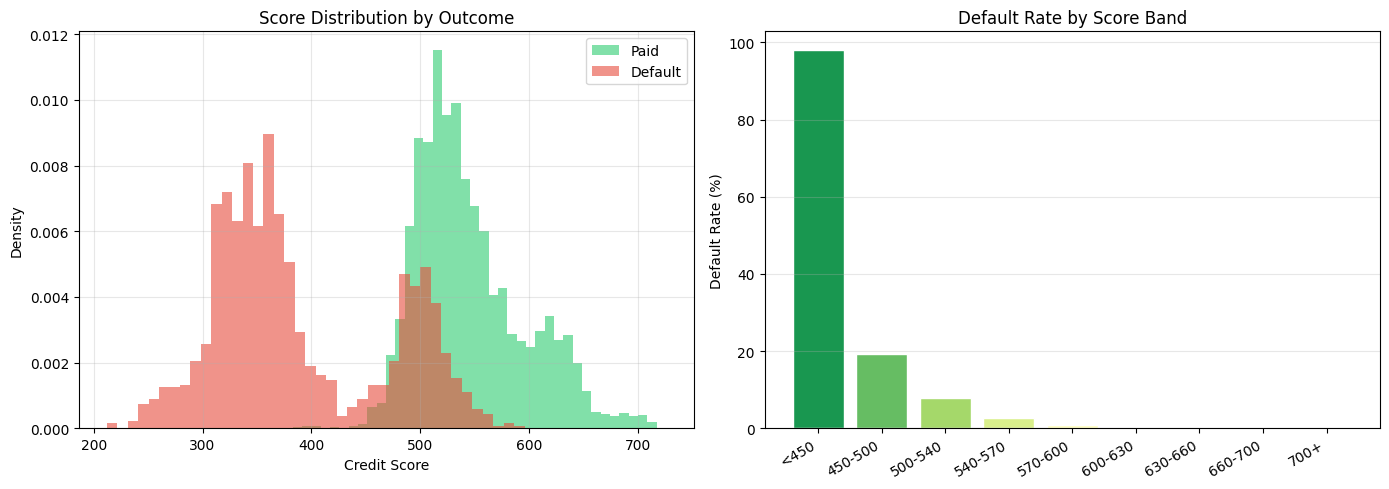

         default_rate     n
band                       
<450         0.979614   932
450-500      0.191406  1024
500-540      0.077209  2150
540-570      0.027719   938
570-600      0.008230   486
600-630      0.000000   449
630-660      0.000000   282
660-700      0.000000    83
700+         0.000000    26


In [ ]:
# Score distribution by actual outcome 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label, colour, name in zip([0, 1], ["#2ecc71","#e74c3c"], ["Paid","Default"]):
    mask = y_test == label
    axes[0].hist(test_scores[mask], bins=40, alpha=0.6,
                 color=colour, label=name, density=True)
axes[0].set_xlabel("Credit Score"); axes[0].set_ylabel("Density")
axes[0].set_title("Score Distribution by Outcome")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Default rate by score band
bands = pd.cut(test_scores,
               bins=[300,450,500,540,570,600,630,660,700,850],
               labels=["<450","450-500","500-540","540-570","570-600",
                        "600-630","630-660","660-700","700+"])
score_df = pd.DataFrame({"band": bands, "default": y_test.values})
band_summary = (score_df.groupby("band", observed=False)["default"]
                  .agg(["mean","count"])
                  .rename(columns={"mean":"default_rate","count":"n"}))

axes[1].bar(range(len(band_summary)), band_summary["default_rate"]*100,
            color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(band_summary))),
            edgecolor="white")
axes[1].set_xticks(range(len(band_summary)))
axes[1].set_xticklabels(band_summary.index, rotation=30, ha="right")
axes[1].set_ylabel("Default Rate (%)")
axes[1].set_title("Default Rate by Score Band")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()
print(band_summary.to_string())

In [ ]:
# Isotonic calibration (improve probability reliability) 
calibrated_model = CalibratedClassifierCV(best_pipe, cv=5, method="isotonic")
calibrated_model.fit(X_train, y_train)
cal_proba = calibrated_model.predict_proba(X_test)[:, 1]

print("Before calibration — Brier score:", round(brier_score_loss(y_test, best_proba), 4))
print("After  calibration — Brier score:", round(brier_score_loss(y_test, cal_proba), 4))
print("Before calibration — AUC:", round(roc_auc_score(y_test, best_proba), 4))
print("After  calibration — AUC:", round(roc_auc_score(y_test, cal_proba), 4))

Before calibration — Brier score: 0.0815
After  calibration — Brier score: 0.0543
Before calibration — AUC: 0.9393
After  calibration — AUC: 0.9393


In [ ]:
# Save final artefacts
import os
os.makedirs("model_artifacts", exist_ok=True)

joblib.dump(calibrated_model,  "model_artifacts/credit_risk_model.pkl")
joblib.dump(OPTIMAL_THRESHOLD, "model_artifacts/optimal_threshold.pkl")

# Save feature schema for validation at serving time
feature_schema = {
    "num_features": NUM_FEATURES,
    "cat_features": CAT_FEATURES,
    "target": TARGET,
    "optimal_threshold": float(OPTIMAL_THRESHOLD),
    "model_name": best_name,
    "auc_test": round(roc_auc_score(y_test, best_proba), 4),
    "ks_test":  ks_statistic(y_test, best_proba),
    "gini_test":gini_coefficient(y_test, best_proba),
}
with open("model_artifacts/model_schema.json", "w") as f:
    json.dump(feature_schema, f, indent=2)

print("Artefacts saved:")
for f in os.listdir("model_artifacts"):
    print(f"model_artifacts/{f}")

Artefacts saved:
model_artifacts/credit_risk_model.pkl
model_artifacts/MODEL_CARD.md
model_artifacts/model_schema.json
model_artifacts/optimal_threshold.pkl


In [ ]:
with open("model_artifacts/model_schema.json") as f:
    schema = json.load(f)

model_card = f"""
# Model Card — Credit Risk Classifier

## Model Details
| Field              | Value                       |
|--------------------|-----------------------------|
| Model type         | {schema['model_name']}      |
| Version            | 1.0.0                       |
| Training date      | {pd.Timestamp.today().date()}|
| Target variable    | {schema['target']}          |
| Decision threshold | {schema['optimal_threshold']}|

## Performance (Hold-out Test Set)
| Metric         | Value            |
|----------------|------------------|
| ROC-AUC        | {schema['auc_test']} |
| KS Statistic   | {schema['ks_test']}  |
| Gini           | {schema['gini_test']}|

## Features
**Numerical ({len(schema['num_features'])}):**  
{', '.join(schema['num_features'])}

**Categorical ({len(schema['cat_features'])}):**  
{', '.join(schema['cat_features'])}

## Intended Use
- Binary classification of loan default risk
- Supports credit underwriting decisions
- Threshold tuned to maximise F1 on the minority (default) class

## Limitations
- Trained on historical data; periodic retraining recommended (suggest every 6 months)
- Monitor for demographic drift and fairness metrics in production
- Not a substitute for full underwriting review on borderline cases (score 540-600)

## Explainability
- SHAP TreeExplainer used for global and per-applicant explanations
- All individual decisions can be explained via the /predict endpoint

## Monitoring
- Track PSI (Population Stability Index) on input features monthly
- Alert if AUC on live labelled data drops below 0.75
"""

with open("model_artifacts/MODEL_CARD.md", "w") as f:
    f.write(model_card)

print(model_card)



# Model Card — Credit Risk Classifier

## Model Details
| Field              | Value                       |
|--------------------|-----------------------------|
| Model type         | XGBoost      |
| Version            | 1.0.0                       |
| Training date      | 2026-04-18|
| Target variable    | loan_status          |
| Decision threshold | 0.7599999999999997|

## Performance (Hold-out Test Set)
| Metric         | Value            |
|----------------|------------------|
| ROC-AUC        | 0.9393 |
| KS Statistic   | 0.7311  |
| Gini           | 0.8787|

## Features
**Numerical (14):**  
person_age, log_income, person_emp_length, loan_amnt, loan_int_rate, loan_percent_income, cb_person_cred_hist_length, dti_ratio, loan_per_hist_year, age_emp_ratio, grade_score, person_emp_length_missing, loan_int_rate_missing, prior_default

**Categorical (3):**  
person_home_ownership, loan_intent, loan_risk_tier

## Intended Use
- Binary classification of loan default risk
- Supports cr